# IT3051 – Telco Customer Churn Prediction
## Model Evaluation and Comparison

This notebook compares the team's four final models **on one common evaluation framework**:

| Model | Notebook | Final model |
|---|---|---|
| Logistic Regression | `LogisticRegression/Logistic_Regression.ipynb` | re-fitted here from its final hyperparameters (not saved to `models/`) |
| Decision Tree | `DecissionTree/Decision_Tree_Model.ipynb` | `models/decision_tree_final.pkl` |
| Random Forest | `RandomForest/Random_Forest_Model.ipynb` | `models/random_forest_final.pkl` |
| XGBoost | `XGBoost/XGBoost_Model.ipynb` | `models/xgboost_final.pkl` (+ threshold in `xgboost_final_metadata.json`) |

Each member's notebook reports different metrics in different ways. Here every model is scored on the **same 1,409
test customers** and the **same 5 cross-validation folds**, with the same metrics, so the results are directly
comparable.

**Outputs for the report** – every chart is saved as a PNG (and every table as a CSV) in the `figures/` folder
next to this notebook:

| File | Content |
|---|---|
| `fig1_test_metrics.png` | Test-set metrics of the four models |
| `fig2_cv_folds.png` | F1 and ROC-AUC per cross-validation fold |
| `fig3_roc_pr_curves.png` | ROC and precision–recall curves |
| `fig4_confusion_matrices.png` | Confusion matrices |
| `fig5_threshold_curves.png` | F1 vs decision threshold (out-of-fold) |
| `fig6_baseline_vs_tuned.png` | Baseline vs tuned test F1 and ROC-AUC |
| `fig7_overfitting.png` | Training vs cross-validated F1 |
| `fig8_permutation_importance.png` | Permutation importance across models |
| `table*.csv` | All result tables |

## 0. Setup

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

%matplotlib inline
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
ROOT = Path("../../..")                 # this notebook lives in Notebook/modelCreation/ModelComparison/
MODEL_DIR = ROOT / "models"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# One fixed colour per model, used in every chart
ORDER = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"]
COLORS = {"Logistic Regression": "#eb6834", "Decision Tree": "#eda100",
          "Random Forest": "#1baf7a", "XGBoost": "#2a78d6"}
SHORT = {"Logistic Regression": "Logistic Reg.", "Decision Tree": "Decision Tree",
         "Random Forest": "Random Forest", "XGBoost": "XGBoost"}
INK, INK2, GRID, GREY = "#0b0b0b", "#52514e", "#e4e3df", "#c9c7c1"

plt.rcParams.update({
    "font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "legend.frameon": False,
})


def save(fig, name):
    """Save a figure for the report (high resolution, tight crop)."""
    fig.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight")
    print("saved", FIG_DIR / name)

## 1. Load the data and the final models

All four models were trained on the same processed data (`train_processed.csv` / `test_processed.csv`, identical to
the files in `SplitData/`): 5,634 training and 1,409 test customers, 57 columns, 26.5% churners.

In [2]:
train_df = pd.read_csv(ROOT / "train_processed.csv")
test_df = pd.read_csv(ROOT / "test_processed.csv")
TARGET = "Churn Label"
X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]
print("Train:", X_train.shape, "| Test:", X_test.shape, "| churn rate:", round(y_train.mean(), 4))

xgb_meta = json.load(open(MODEL_DIR / "xgboost_final_metadata.json"))

# Final (tuned) models
final_models = {
    # Logistic Regression was not saved, so it is re-fitted from the GridSearchCV best parameters
    "Logistic Regression": LogisticRegression(class_weight="balanced", C=10, l1_ratio=0.0, solver="saga",
                                              max_iter=1000, random_state=RANDOM_STATE).fit(X_train, y_train),
    "Decision Tree": joblib.load(MODEL_DIR / "decision_tree_final.pkl"),
    "Random Forest": joblib.load(MODEL_DIR / "random_forest_final.pkl"),
    "XGBoost": joblib.load(MODEL_DIR / "xgboost_final.pkl"),
}
# Decision threshold each model uses in practice
thresholds = {"Logistic Regression": 0.5, "Decision Tree": 0.5, "Random Forest": 0.5,
              "XGBoost": xgb_meta["decision_threshold"]}

# Baselines = each member's untuned starting model
baseline_models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
}

for name, m in final_models.items():
    print(f"{name:<20} {type(m).__name__:<24} threshold {thresholds[name]}")

Train: (5634, 57) | Test: (1409, 57) | churn rate: 0.2654


Logistic Regression  LogisticRegression       threshold 0.5
Decision Tree        DecisionTreeClassifier   threshold 0.5
Random Forest        RandomForestClassifier   threshold 0.5
XGBoost              XGBClassifier            threshold 0.51


In [3]:
def scores(y_true, y_pred, y_proba):
    return {"Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred),
            "F1": f1_score(y_true, y_pred),
            "ROC-AUC": roc_auc_score(y_true, y_proba),
            "PR-AUC": average_precision_score(y_true, y_proba)}

METRICS = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]

# Test-set probabilities and predictions of every final model
proba = {n: final_models[n].predict_proba(X_test)[:, 1] for n in ORDER}
pred = {n: (proba[n] >= thresholds[n]).astype(int) for n in ORDER}

## 2. Test-set results

**Metrics.** F1 on the churn class is the primary metric (balances missed churners and false alarms). Recall and
precision show the two error types separately. ROC-AUC and PR-AUC measure how well a model *ranks* customers by risk,
independent of the threshold; PR-AUC focuses on the minority class (no-skill value = churn rate 0.265). Accuracy is
shown but not used for selection, because always predicting "no churn" already scores 73.5%.

In [4]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
test_results = {"Dummy (always 'no churn')": scores(y_test, dummy.predict(X_test), dummy.predict_proba(X_test)[:, 1])}
for n in ORDER:
    test_results[n] = scores(y_test, pred[n], proba[n])

table1 = pd.DataFrame(test_results).T
table1.insert(0, "Threshold", ["–"] + [thresholds[n] for n in ORDER])
table1.to_csv(FIG_DIR / "table1_test_metrics.csv")
table1.round(4)

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Dummy (always 'no churn'),–,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654
Logistic Regression,0.5,0.7991,0.5823,0.8610,0.6947,0.9004,0.7551
Decision Tree,0.5,0.7708,0.5440,0.8422,0.6611,0.8718,0.6927
Random Forest,0.5,0.8446,0.7476,0.6257,0.6812,0.8965,0.7534
XGBoost,0.51,0.8432,0.6835,0.7620,0.7206,0.9142,0.7887


saved figures\fig1_test_metrics.png


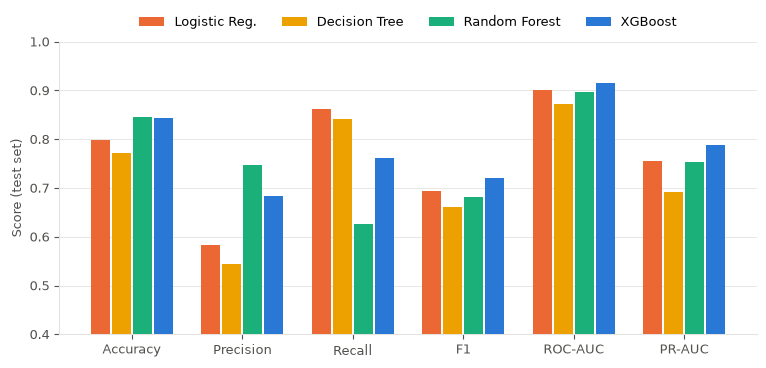

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.8))
width = 0.19
x = np.arange(len(METRICS))
for i, n in enumerate(ORDER):
    ax.bar(x + (i - 1.5) * width, [test_results[n][m] for m in METRICS], width - 0.02,
           color=COLORS[n], label=SHORT[n], zorder=3)
ax.set_xticks(x, METRICS)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("Score (test set)")
ax.grid(axis="x", visible=False)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.13))
save(fig, "fig1_test_metrics.png")
plt.show()

**Interpretation.** XGBoost is best on F1, ROC-AUC and PR-AUC. Random Forest has the highest accuracy and precision
but misses the most churners; Logistic Regression and Decision Tree catch the most churners (highest recall) but
raise many false alarms. Each model makes a different precision–recall trade-off; the threshold-free ROC-AUC and
PR-AUC show that XGBoost also ranks customers best.

## 3. Cross-validation on identical folds

Every final model configuration is re-trained and scored on the **same** 5 stratified folds of the training data.
The training-minus-validation F1 gap measures overfitting.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CV_SCORING = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1",
              "roc_auc": "roc_auc", "pr_auc": "average_precision"}


def run_cv(model):
    est = clone(model)
    if isinstance(est, XGBClassifier):
        est.set_params(n_jobs=1)          # parallelise over folds instead
    return cross_validate(est, X_train, y_train, cv=cv, scoring=CV_SCORING, return_train_score=True, n_jobs=-1)


cv_final = {n: run_cv(final_models[n]) for n in ORDER}
cv_base = {n: run_cv(baseline_models[n]) for n in ORDER}

rows = {}
for n in ORDER:
    r = cv_final[n]
    rows[n] = {**{f"{m} (mean)": r[f"test_{m}"].mean() for m in CV_SCORING},
               **{f"{m} (std)": r[f"test_{m}"].std() for m in ["f1", "roc_auc", "pr_auc"]},
               "train F1": r["train_f1"].mean(),
               "F1 gap (train - CV)": r["train_f1"].mean() - r["test_f1"].mean()}
table2 = pd.DataFrame(rows).T
table2.to_csv(FIG_DIR / "table2_cross_validation.csv")
table2.round(4)

,accuracy (mean),precision (mean),recall (mean),f1 (mean),roc_auc (mean),pr_auc (mean),f1 (std),roc_auc (std),pr_auc (std),train F1,F1 gap (train - CV)
Logistic Regression,0.7955,0.5790,0.8482,0.6880,0.8951,0.7576,0.0231,0.0047,0.0089,0.6927,0.0046
Decision Tree,0.7820,0.5615,0.8355,0.6709,0.8715,0.6878,0.0243,0.0129,0.0229,0.6995,0.0286
Random Forest,0.8459,0.7581,0.6167,0.6799,0.8982,0.7710,0.0114,0.0056,0.0150,0.8048,0.1249
XGBoost,0.8422,0.6810,0.7632,0.7196,0.9075,0.7859,0.0185,0.0084,0.0176,0.7706,0.0509


saved figures\fig2_cv_folds.png


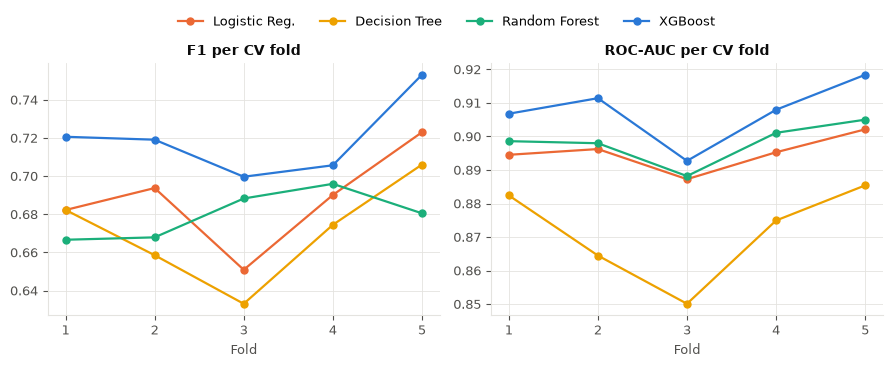

XGBoost wins on f1: {'Logistic Regression': 5, 'Decision Tree': 5, 'Random Forest': 5} (out of 5 folds)
XGBoost wins on roc_auc: {'Logistic Regression': 5, 'Decision Tree': 5, 'Random Forest': 5} (out of 5 folds)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, metric, title in [(axes[0], "test_f1", "F1 per CV fold"), (axes[1], "test_roc_auc", "ROC-AUC per CV fold")]:
    for n in ORDER:
        ax.plot(range(1, 6), cv_final[n][metric], marker="o", ms=5, lw=1.6, color=COLORS[n], label=SHORT[n])
    ax.set_xticks(range(1, 6))
    ax.set_xlabel("Fold")
    ax.set_title(title)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()
save(fig, "fig2_cv_folds.png")
plt.show()

for m in ["test_f1", "test_roc_auc"]:
    wins = {n: int((cv_final["XGBoost"][m] > cv_final[n][m]).sum()) for n in ORDER if n != "XGBoost"}
    print(f"XGBoost wins on {m[5:]}:", wins, "(out of 5 folds)")

**Interpretation.** The cross-validation results agree with the test set, and the fold-by-fold chart shows XGBoost's
lead is consistent rather than the result of one lucky split. Logistic Regression barely overfits (smallest gap);
Random Forest overfits the most of the tuned models.

## 4. ROC and precision–recall curves

The curves show performance at **every** possible threshold. A curve that lies above another offers a better
trade-off at any operating point.

saved figures\fig3_roc_pr_curves.png


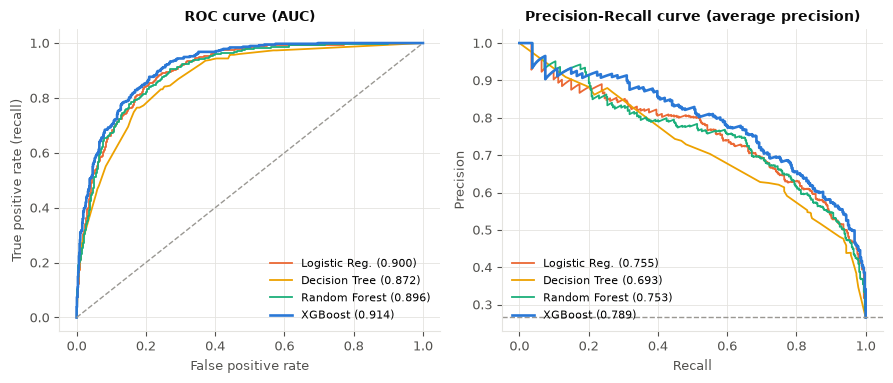

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.9))
for n in ORDER:
    fpr, tpr, _ = roc_curve(y_test, proba[n])
    lw = 1.9 if n == "XGBoost" else 1.3
    axes[0].plot(fpr, tpr, color=COLORS[n], lw=lw, label=f"{SHORT[n]} ({test_results[n]['ROC-AUC']:.3f})")
    p, r, _ = precision_recall_curve(y_test, proba[n])
    axes[1].plot(r, p, color=COLORS[n], lw=lw, label=f"{SHORT[n]} ({test_results[n]['PR-AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="#9a9893", lw=1)
axes[1].axhline(y_test.mean(), ls="--", color="#9a9893", lw=1)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate (recall)", title="ROC curve (AUC)")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curve (average precision)")
axes[0].legend(loc="lower right", fontsize=8)
axes[1].legend(loc="lower left", fontsize=8)
fig.tight_layout()
save(fig, "fig3_roc_pr_curves.png")
plt.show()

**Interpretation.** XGBoost's curves lie on or above the others almost everywhere. The Decision Tree's curves are
stepped because a single pruned tree can only output a few distinct probabilities, which limits how finely it can
rank customers.

## 5. Confusion matrices and errors in business terms

Test set: 374 churners and 1,035 non-churners, each model at its own decision threshold.

saved figures\fig4_confusion_matrices.png


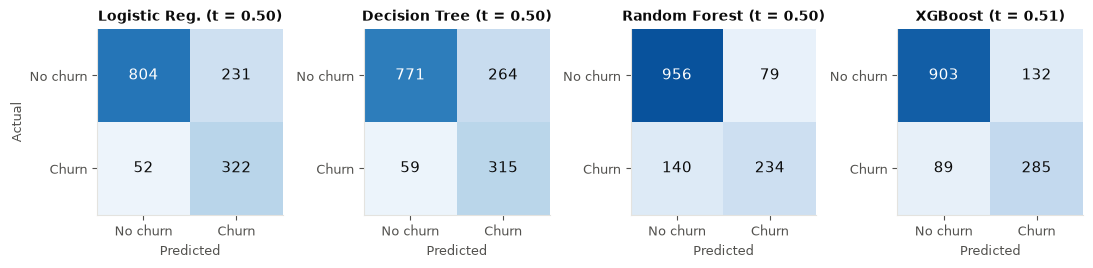

,Churners caught (TP),Churners missed (FN),False alarms (FP),Correct non-churners (TN),Flagged who really churn
Logistic Regression,322,52,231,804,58%
Decision Tree,315,59,264,771,54%
Random Forest,234,140,79,956,75%
XGBoost,285,89,132,903,68%


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.9))
error_rows = {}
for ax, n in zip(axes, ORDER):
    cm = confusion_matrix(y_test, pred[n])
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=1100)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center", fontsize=11, color="white" if v > 550 else INK)
    ax.set_xticks([0, 1], ["No churn", "Churn"])
    ax.set_yticks([0, 1], ["No churn", "Churn"])
    ax.grid(False)
    ax.set_title(f"{SHORT[n]} (t = {thresholds[n]:.2f})")
    ax.set_xlabel("Predicted")
    (tn, fp), (fn, tp) = cm
    error_rows[n] = {"Churners caught (TP)": tp, "Churners missed (FN)": fn, "False alarms (FP)": fp,
                     "Correct non-churners (TN)": tn, "Flagged who really churn": f"{tp / (tp + fp):.0%}"}
axes[0].set_ylabel("Actual")
fig.tight_layout()
save(fig, "fig4_confusion_matrices.png")
plt.show()

table3 = pd.DataFrame(error_rows).T
table3.to_csv(FIG_DIR / "table3_errors.csv")
table3

**Interpretation.** Logistic Regression and Decision Tree catch the most churners but 42–46% of the customers they flag
would not have churned. Random Forest raises the fewest false alarms but misses the most churners – the most
expensive error for the business. XGBoost gives the best balance: about two out of three flagged customers really
are at risk.

## 6. Is the difference real? Paired bootstrap on the test set

The test set is resampled with replacement 1,000 times and every model re-scored on each resample. If the 95%
confidence interval of a difference lies entirely above zero, XGBoost's lead is unlikely to be a lucky split.

In [10]:
rng = np.random.default_rng(RANDOM_STATE)
y_arr = y_test.values
boot = {n: {"F1": [], "ROC-AUC": [], "PR-AUC": []} for n in ORDER}
for _ in range(1000):
    idx = rng.integers(0, len(y_arr), len(y_arr))
    for n in ORDER:
        p_ = proba[n][idx]
        boot[n]["F1"].append(f1_score(y_arr[idx], (p_ >= thresholds[n]).astype(int)))
        boot[n]["ROC-AUC"].append(roc_auc_score(y_arr[idx], p_))
        boot[n]["PR-AUC"].append(average_precision_score(y_arr[idx], p_))

rows = {}
for n in ["Logistic Regression", "Decision Tree", "Random Forest"]:
    row = {}
    for m in ["F1", "ROC-AUC", "PR-AUC"]:
        d = np.array(boot["XGBoost"][m]) - np.array(boot[n][m])
        row[f"Δ {m}"] = round(test_results["XGBoost"][m] - test_results[n][m], 3)
        row[f"Δ {m} 95% CI"] = f"[{np.percentile(d, 2.5):+.3f}, {np.percentile(d, 97.5):+.3f}]"
    row["P(XGBoost better on F1)"] = f"{(np.array(boot['XGBoost']['F1']) > np.array(boot[n]['F1'])).mean():.1%}"
    rows[f"XGBoost − {n}"] = row
table4 = pd.DataFrame(rows).T
table4.to_csv(FIG_DIR / "table4_bootstrap.csv")
table4

,Δ F1,Δ F1 95% CI,Δ ROC-AUC,Δ ROC-AUC 95% CI,Δ PR-AUC,Δ PR-AUC 95% CI,P(XGBoost better on F1)
XGBoost − Logistic Regression,0.026,"[+0.002, +0.051]",0.014,"[+0.006, +0.021]",0.034,"[+0.008, +0.058]",98.3%
XGBoost − Decision Tree,0.06,"[+0.029, +0.088]",0.042,"[+0.030, +0.055]",0.096,"[+0.067, +0.125]",99.9%
XGBoost − Random Forest,0.039,"[+0.010, +0.069]",0.018,"[+0.011, +0.024]",0.035,"[+0.018, +0.054]",99.4%


## 7. A fairer comparison: every model at its own best threshold

Each member chose a different class-weighting strategy, so F1 at the default 0.5 threshold partly reflects that
choice. Here each model's threshold is chosen to maximise F1 on **out-of-fold training predictions** (never on the
test set) and then applied once to the test set.

In [11]:
grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
oof_f1_curves, rows = {}, {}
for n in ORDER:
    est = clone(final_models[n])
    if isinstance(est, XGBClassifier):
        est.set_params(n_jobs=1)
    oof = cross_val_predict(est, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    curve = np.array([f1_score(y_train, oof >= t) for t in grid])
    oof_f1_curves[n] = curve
    best_t = float(grid[curve.argmax()])
    s = scores(y_test, (proba[n] >= best_t).astype(int), proba[n])
    rows[n] = {"Best OOF threshold": best_t, "OOF F1 (train)": curve.max(), "Test precision": s["Precision"],
               "Test recall": s["Recall"], "Test F1": s["F1"], "Test F1 at own default": test_results[n]["F1"]}
table5 = pd.DataFrame(rows).T
table5.to_csv(FIG_DIR / "table5_best_thresholds.csv")
table5.round(4)

,Best OOF threshold,OOF F1 (train),Test precision,Test recall,Test F1,Test F1 at own default
Logistic Regression,0.66,0.6977,0.6643,0.7353,0.6980,0.6947
Decision Tree,0.59,0.6801,0.6208,0.7487,0.6788,0.6611
Random Forest,0.39,0.7016,0.6659,0.7460,0.7037,0.6812
XGBoost,0.51,0.7207,0.6835,0.7620,0.7206,0.7206


saved figures\fig5_threshold_curves.png


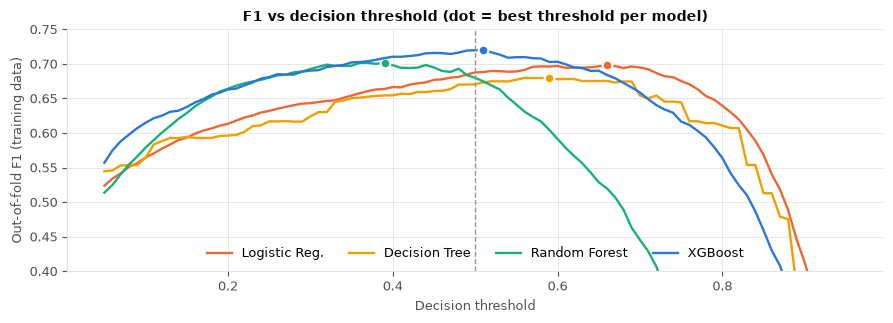

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.3))
for n in ORDER:
    ax.plot(grid, oof_f1_curves[n], color=COLORS[n], lw=1.7, label=SHORT[n])
    ax.plot([table5.loc[n, "Best OOF threshold"]], [oof_f1_curves[n].max()], "o", color=COLORS[n], ms=7,
            mec="white", mew=1.5)
ax.axvline(0.5, ls="--", color="#9a9893", lw=1)
ax.set(xlabel="Decision threshold", ylabel="Out-of-fold F1 (training data)", ylim=(0.4, 0.75),
       title="F1 vs decision threshold (dot = best threshold per model)")
ax.legend(ncol=4, loc="lower center")
fig.tight_layout()
save(fig, "fig5_threshold_curves.png")
plt.show()

**Interpretation.** With thresholds optimised, the ranking does not change – XGBoost is still first. Random Forest
gains the most because its default 0.5 cut-off is far from its optimum; Logistic Regression's and Decision Tree's
optima lie above 0.5 because balanced class weights over-weight churners.

## 8. Effect of tuning: baseline vs final model

Each member's untuned baseline compared with their final tuned model, on the test set and on the training data
(to show overfitting).

In [13]:
base_results = {}
for n in ORDER:
    b = clone(baseline_models[n]).fit(X_train, y_train)
    bp = b.predict_proba(X_test)[:, 1]
    base_results[n] = scores(y_test, (bp >= 0.5).astype(int), bp)

table6 = pd.DataFrame({
    "Baseline test F1": {n: base_results[n]["F1"] for n in ORDER},
    "Final test F1": {n: test_results[n]["F1"] for n in ORDER},
    "F1 gain": {n: test_results[n]["F1"] - base_results[n]["F1"] for n in ORDER},
    "Baseline test ROC-AUC": {n: base_results[n]["ROC-AUC"] for n in ORDER},
    "Final test ROC-AUC": {n: test_results[n]["ROC-AUC"] for n in ORDER},
    "Baseline train F1": {n: cv_base[n]["train_f1"].mean() for n in ORDER},
    "Baseline CV F1": {n: cv_base[n]["test_f1"].mean() for n in ORDER},
    "Final train F1": {n: cv_final[n]["train_f1"].mean() for n in ORDER},
    "Final CV F1": {n: cv_final[n]["test_f1"].mean() for n in ORDER},
})
table6.to_csv(FIG_DIR / "table6_baseline_vs_tuned.csv")
table6.round(4)

,Baseline test F1,Final test F1,F1 gain,Baseline test ROC-AUC,Final test ROC-AUC,Baseline train F1,Baseline CV F1,Final train F1,Final CV F1
Logistic Regression,0.6947,0.6947,0.0000,0.9004,0.9004,0.6929,0.6881,0.6927,0.6880
Decision Tree,0.6130,0.6611,0.0480,0.7392,0.8718,1.0000,0.5951,0.6995,0.6709
Random Forest,0.6696,0.6812,0.0116,0.8917,0.8965,1.0000,0.6640,0.8048,0.6799
XGBoost,0.6844,0.7206,0.0362,0.9037,0.9142,0.9941,0.6642,0.7706,0.7196


saved figures\fig6_baseline_vs_tuned.png


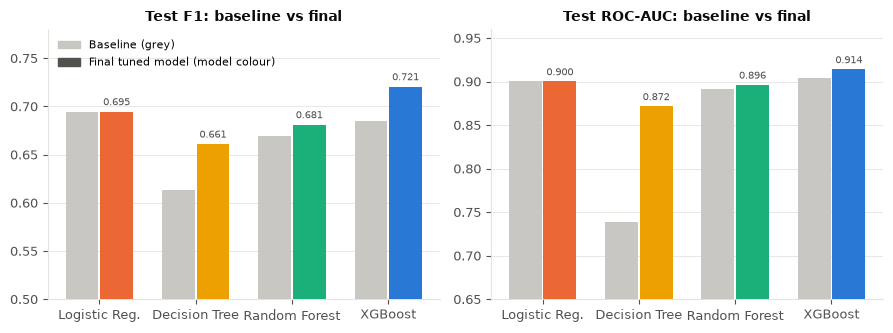

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, m, ylim in [(axes[0], "F1", (0.5, 0.78)), (axes[1], "ROC-AUC", (0.65, 0.96))]:
    for i, n in enumerate(ORDER):
        ax.bar(i - 0.18, base_results[n][m], 0.34, color=GREY, zorder=3)
        ax.bar(i + 0.18, test_results[n][m], 0.34, color=COLORS[n], zorder=3)
        ax.text(i + 0.18, test_results[n][m] + 0.004, f"{test_results[n][m]:.3f}", ha="center", va="bottom",
                fontsize=7.5, color=INK2)
    ax.set_xticks(range(4), [SHORT[n] for n in ORDER])
    ax.set_ylim(*ylim)
    ax.set_title(f"Test {m}: baseline vs final")
    ax.grid(axis="x", visible=False)
axes[0].legend(handles=[Patch(color=GREY, label="Baseline (grey)"),
                        Patch(color=INK2, label="Final tuned model (model colour)")], loc="upper left", fontsize=8)
fig.tight_layout()
save(fig, "fig6_baseline_vs_tuned.png")
plt.show()

saved figures\fig7_overfitting.png


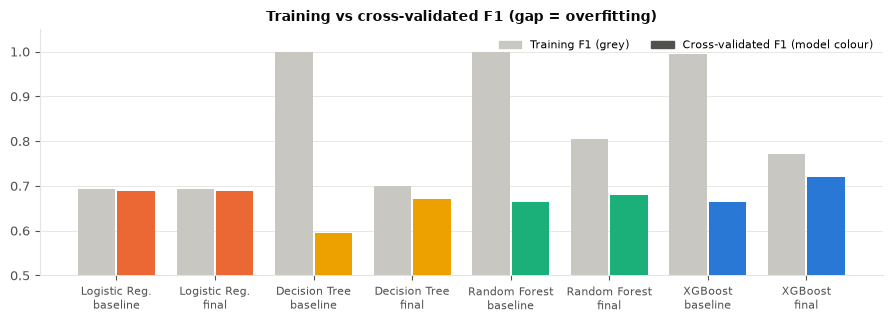

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.3))
labels, train_vals, cv_vals, cols = [], [], [], []
for n in ORDER:
    for kind, res in [("baseline", cv_base[n]), ("final", cv_final[n])]:
        labels.append(f"{SHORT[n]}\n{kind}")
        train_vals.append(res["train_f1"].mean())
        cv_vals.append(res["test_f1"].mean())
        cols.append(COLORS[n])
x = np.arange(len(labels))
ax.bar(x - 0.2, train_vals, 0.38, color=GREY, zorder=3)
ax.bar(x + 0.2, cv_vals, 0.38, color=cols, zorder=3)
ax.set_xticks(x, labels, fontsize=8)
ax.set_ylim(0.5, 1.05)
ax.set_title("Training vs cross-validated F1 (gap = overfitting)")
ax.legend(handles=[Patch(color=GREY, label="Training F1 (grey)"),
                   Patch(color=INK2, label="Cross-validated F1 (model colour)")],
          loc="upper right", ncol=2, fontsize=8)
ax.grid(axis="x", visible=False)
fig.tight_layout()
save(fig, "fig7_overfitting.png")
plt.show()

**Interpretation.** Three baselines memorised the training data (training F1 ≈ 1.0): the unpruned Decision Tree, the
fully-grown Random Forest and default XGBoost. Tuning their complexity closed most of that gap and improved test F1.
Logistic Regression never overfitted, so tuning had nothing to fix and its predictions did not change.

## 9. What drives the predictions? Permutation importance

To compare the four models on one scale, permutation importance measures how much test ROC-AUC drops when one
feature's values are randomly shuffled. The chart shows every feature that is in the top 6 of at least one model.

saved figures\fig8_permutation_importance.png


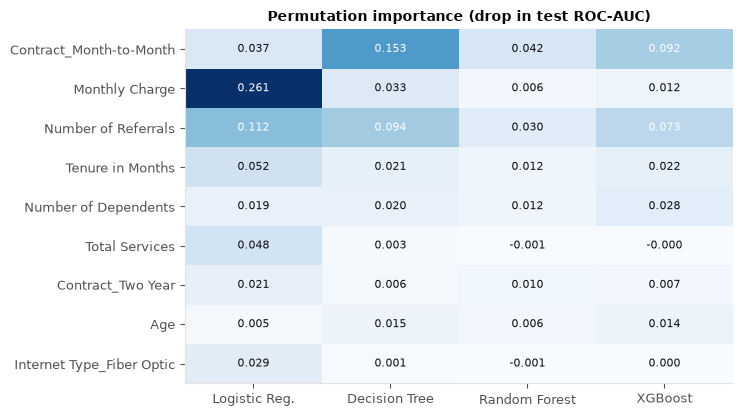

In [16]:
perm = {}
for n in ORDER:
    r = permutation_importance(final_models[n], X_test, y_test, scoring="roc_auc", n_repeats=10,
                               random_state=RANDOM_STATE, n_jobs=-1)
    perm[n] = pd.Series(r.importances_mean, index=X_test.columns)
perm = pd.DataFrame(perm)[ORDER]
perm.sort_values("XGBoost", ascending=False).to_csv(FIG_DIR / "table7_permutation_importance.csv")

top = sorted(set().union(*[perm[c].nlargest(6).index for c in ORDER]), key=lambda f: -perm.loc[f].mean())
sub = perm.loc[top]
fig, ax = plt.subplots(figsize=(7.5, 0.36 * len(top) + 1.0))
ax.imshow(sub.values, cmap="Blues", aspect="auto", vmin=0, vmax=max(0.12, sub.values.max()))
for (i, j), v in np.ndenumerate(sub.values):
    ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8, color="white" if v > 0.06 else INK)
ax.set_xticks(range(4), [SHORT[n] for n in ORDER])
ax.set_yticks(range(len(top)), [t.replace("num__", "").replace("cat__", "") for t in top])
ax.grid(False)
ax.set_title("Permutation importance (drop in test ROC-AUC)")
fig.tight_layout()
save(fig, "fig8_permutation_importance.png")
plt.show()

**Interpretation.** All four models agree on the main churn drivers: month-to-month contracts and few referrals,
followed by tenure, number of dependents, monthly charge and age. Logistic Regression relies heavily on Monthly
Charge because, as a linear model, it uses the charge as a proxy for the customer's service bundle.

## 10. Summary

In [17]:
summary = pd.DataFrame({
    "Test F1": {n: test_results[n]["F1"] for n in ORDER},
    "Test ROC-AUC": {n: test_results[n]["ROC-AUC"] for n in ORDER},
    "Test PR-AUC": {n: test_results[n]["PR-AUC"] for n in ORDER},
    "Test recall": {n: test_results[n]["Recall"] for n in ORDER},
    "Test precision": {n: test_results[n]["Precision"] for n in ORDER},
    "CV F1": {n: cv_final[n]["test_f1"].mean() for n in ORDER},
    "Best-threshold test F1": {n: table5.loc[n, "Test F1"] for n in ORDER},
})
summary.to_csv(FIG_DIR / "table8_summary.csv")
print("Best model on each metric:")
for col in summary.columns:
    print(f"  {col:<24} {summary[col].idxmax()}")
summary.round(4)

Best model on each metric:
  Test F1                  XGBoost
  Test ROC-AUC             XGBoost
  Test PR-AUC              XGBoost
  Test recall              Logistic Regression
  Test precision           Random Forest
  CV F1                    XGBoost
  Best-threshold test F1   XGBoost


,Test F1,Test ROC-AUC,Test PR-AUC,Test recall,Test precision,CV F1,Best-threshold test F1
Logistic Regression,0.6947,0.9004,0.7551,0.8610,0.5823,0.6880,0.6980
Decision Tree,0.6611,0.8718,0.6927,0.8422,0.5440,0.6709,0.6788
Random Forest,0.6812,0.8965,0.7534,0.6257,0.7476,0.6799,0.7037
XGBoost,0.7206,0.9142,0.7887,0.7620,0.6835,0.7196,0.7206


**Final model: tuned XGBoost (threshold 0.51).** It has the best F1, ROC-AUC and PR-AUC on the test set, beats the
other models in every cross-validation fold, keeps its lead when every model uses its own optimal threshold, and the
bootstrap confidence intervals of its advantage exclude zero. All charts and tables for the report are in the
`figures/` folder.